# INTRODUCTION


## Forest Cover Type Classification
### A Deep Learning Approach to Multi-Class Imbalanced Classification

---

#### Problem Statement
Forest cover type classification is the task of predicting the dominant tree species in a given area of land based purely on cartographic variables — no remotely sensed data is used. Accurate classification has practical applications in forest management, conservation planning and ecological research, where manual field surveys are expensive and time-consuming.

This notebook documents a complete end-to-end machine learning pipeline, from raw data exploration through to model evaluation and ensemble analysis. Three progressively refined approaches are compared:

- **Baseline Model** — a shallow neural network to establish a performance floor
- **Improved Model** — a deeper, regularised architecture with a tuned optimiser
- **Ensemble** — combining both models to determine whether combined predictions outperform either model individually

---

#### Dataset
The dataset used is the **UCI Covertype dataset**, one of the most widely benchmarked datasets in machine learning. It contains cartographic observations collected from the Roosevelt National Forest in Colorado.

| Property | Value |
|----------|-------|
| Total samples | 581,012 |
| Features | 54 (53 after preprocessing) |
| Classes | 7 |
| Feature types | Continuous (10), Binary indicators (44) |
| Source | UCI Machine Learning Repository |

#### Cover Type Classes
| Class ID | Cover Type | Description |
|----------|------------|-------------|
| 0 | Spruce/Fir | High elevation, dense canopy |
| 1 | Lodgepole Pine | Most abundant class in dataset |
| 2 | Ponderosa Pine | Mid-elevation, drier slopes |
| 3 | Cottonwood/Willow | Riparian zones, rarest class |
| 4 | Aspen | Mixed elevations, small stands |
| 5 | Douglas-fir | Mid-elevation, moderate moisture |
| 6 | Krummholz | Treeline, stunted growth |

---

### Why This Problem Is Non-Trivial
Two properties make this dataset particularly challenging:

1. **Severe class imbalance** — Spruce/Fir and Lodgepole Pine together account for over 85% of all samples. Cottonwood/Willow accounts for less than 0.1%. A naive majority-class classifier would achieve deceptively high accuracy while failing completely on rare species.

2. **Feature overlap between species** — ecologically adjacent species (e.g. Ponderosa Pine and Douglas-fir, Spruce/Fir and Lodgepole Pine) occupy similar elevation ranges and terrain profiles, making their cartographic signatures difficult to separate.

These two factors directly shaped every modelling decision made in this project, from the choice of evaluation metric to the use of class weighting.

> **Primary evaluation metric: Macro F1 Score**  
> Because of the class imbalance, overall accuracy is a poor indicator of true 
> model quality. Macro F1 weights all classes equally regardless of their size, 
> making it the most honest measure of whether the model performs well across 
> all seven cover types — not just the dominant ones.

# SETUP & IMPORTS

All project dependencies are imported in this section. The codebase is organised into four scripts:

| File | Purpose |
|------|---------|
| `utils.py` | Shared functions used across all three model scripts |
| `baseline_script.py` | Baseline model training pipeline |
| `improved_script.py` | Improved model training pipeline |
| `ensemble_script.py` | Ensemble evaluation and comparison |

A fixed random seed of **42** is applied across NumPy, scikit-learn and TensorFlow to ensure that all data splits, weight initialisations and dropout masks are reproducible across runs. Without this, results would vary between executions, making meaningful comparison impossible.

# EXPLORATORY DATA ANALYSIS

Before any modelling begins, it is essential to understand the structure, distribution and relationships within the data. The findings from this section directly informed the preprocessing decisions and modelling choices made later in the pipeline.

---

#### Class Distribution

The bar chart below shows the number of samples per cover type. The imbalance is immediately visible — Lodgepole Pine alone contains more samples than all five minority classes combined.

class
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


<Axes: xlabel='class', ylabel='count'>

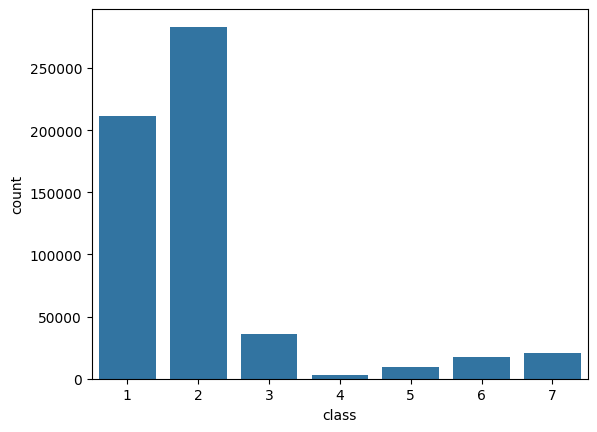

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../cover_data.csv')

print(df['class'].value_counts())
sns.countplot(x='class', data=df)

This imbalance has direct consequences for training:
- A model trained without correction will learn to optimise for Spruce/Fir and Lodgepole Pine at the expense of all other classes
- Accuracy becomes a misleading metric — a model that only predicts the two dominant classes would still score over 85% accuracy
- **Class weighting** is required to give the model an equal incentive to correctly classify each cover type

---

#### Feature Distributions

The dataset contains two distinct types of features:

**Continuous features (9):**
These represent physical terrain measurements such as elevation, slope, aspect and distance to water and roads. They vary significantly in scale — for example, elevation ranges from ~1,800m to ~3,800m while slope values fall between 0 and 66 degrees. Standardisation is necessary before feeding these into a neural network, as large-scale features would otherwise dominate gradient updates.

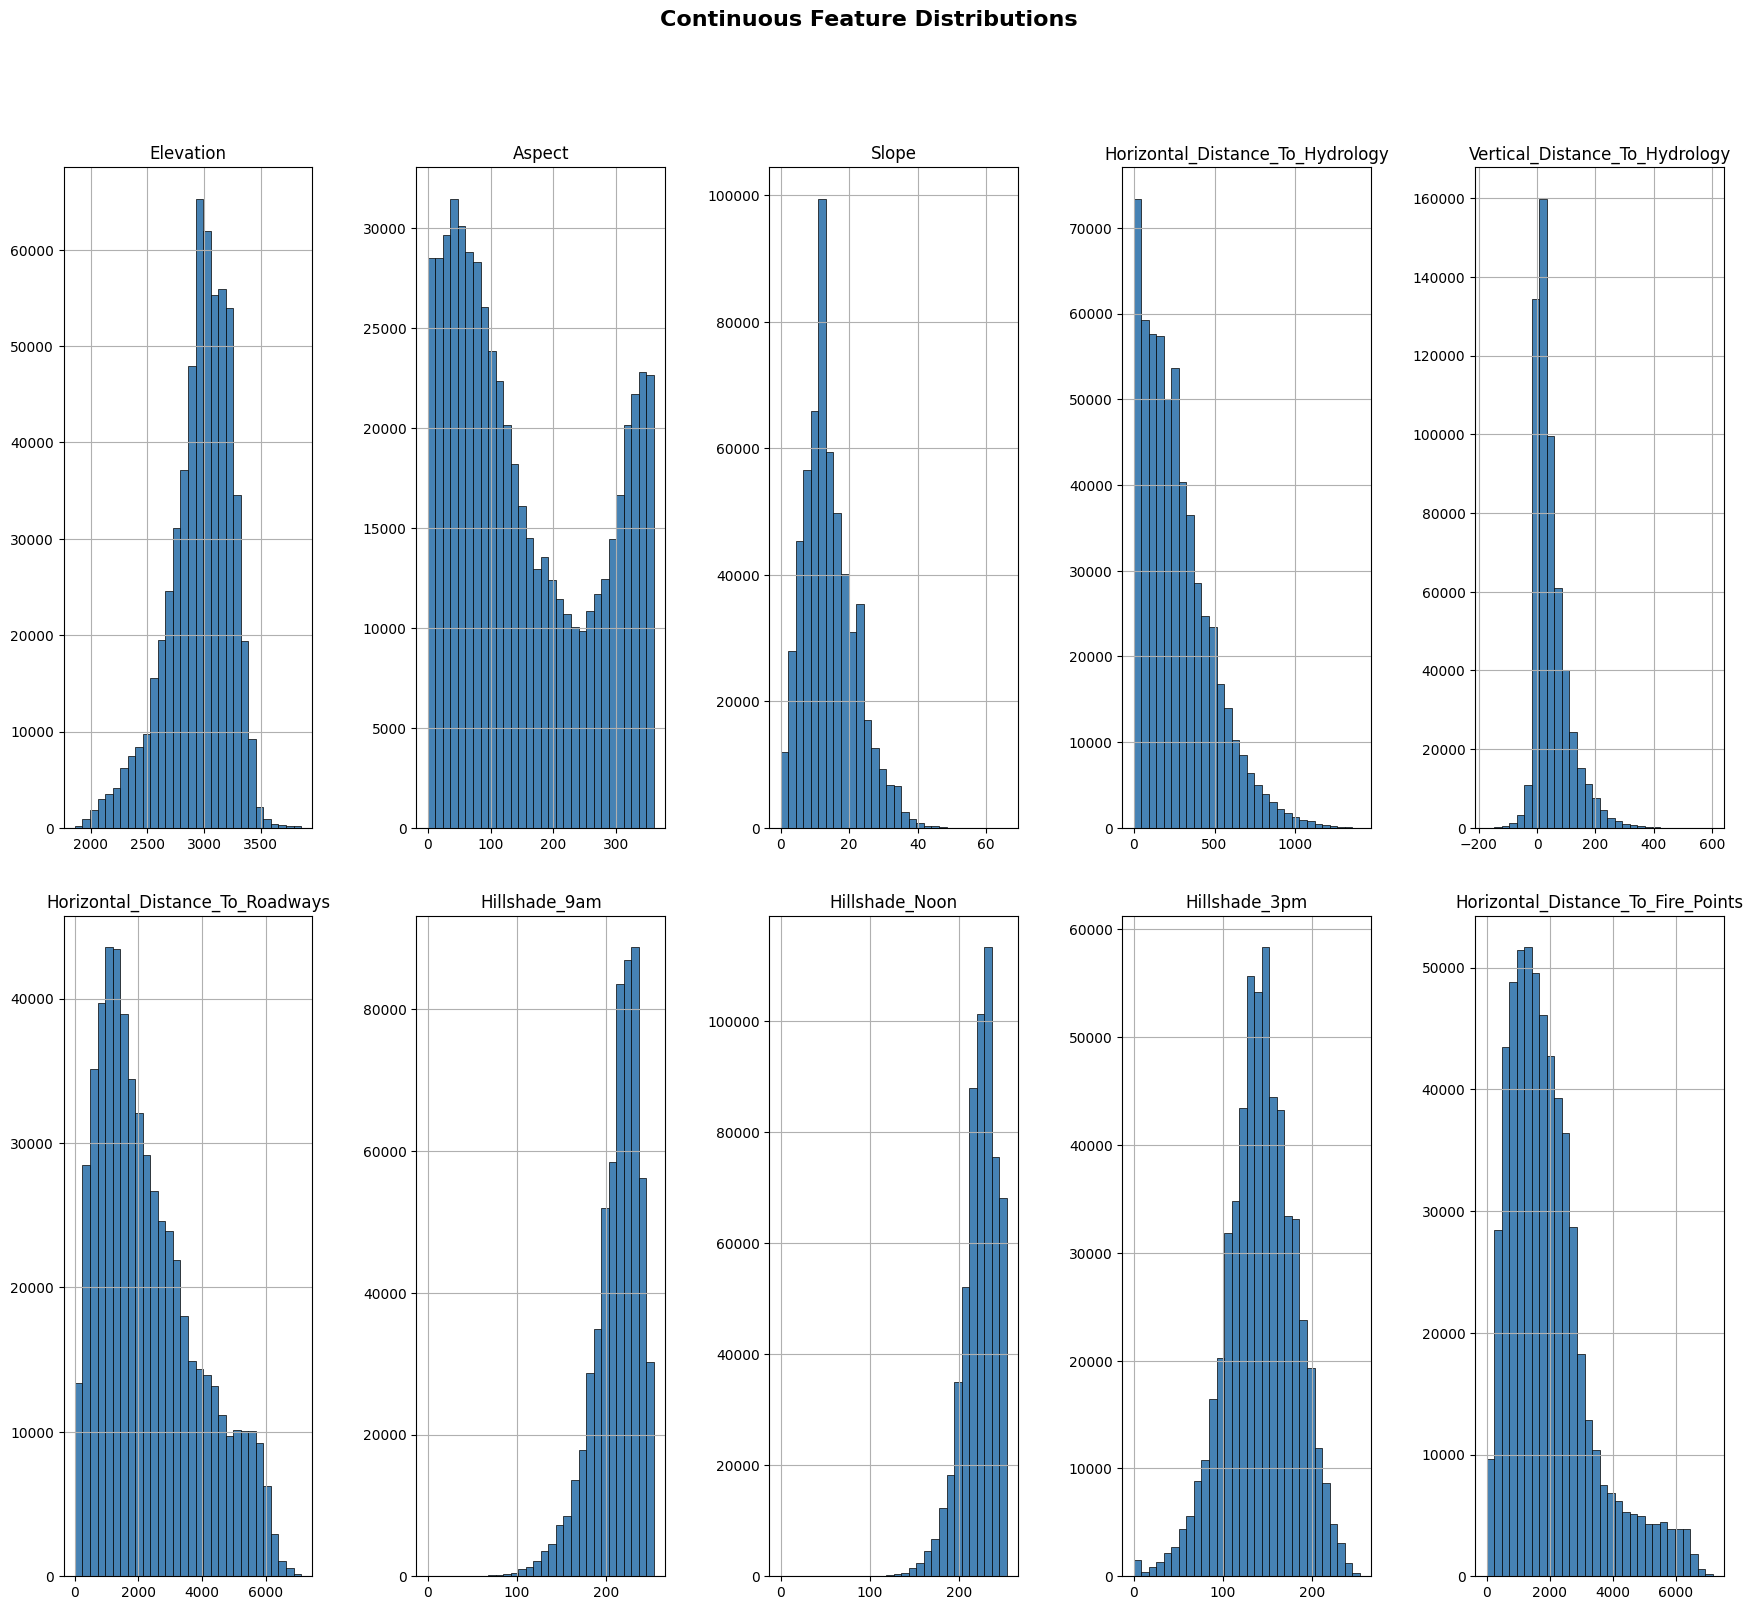

In [22]:
# 5. Feature distributions
continuous_features = df.iloc[:, :10]
fig, axes = plt.subplots(2, 5, figsize=(18, 16))
continuous_features.hist(
    ax=axes,
    bins=30,             # more bins for smoother distribution view
    color='steelblue',
    edgecolor='black',   # bar borders for clarity
    linewidth=0.5
)

plt.suptitle('Continuous Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)          # increase padding between subplots
plt.show()

**Binary indicator features (44):**
These encode wilderness area membership (4 features) and soil type (40 features) as one-hot style indicators. Because they are already encoded as 0 or 1, scaling them would distort their meaning — a scaled value of 0.5 between "is this soil type" and "is not this soil type" has no real-world interpretation. These features are passed through the pipeline unchanged.

---

#### Correlation Analysis & Feature Selection

A Pearson correlation matrix was computed across all continuous features to identify redundant variables before modelling.

<Axes: >

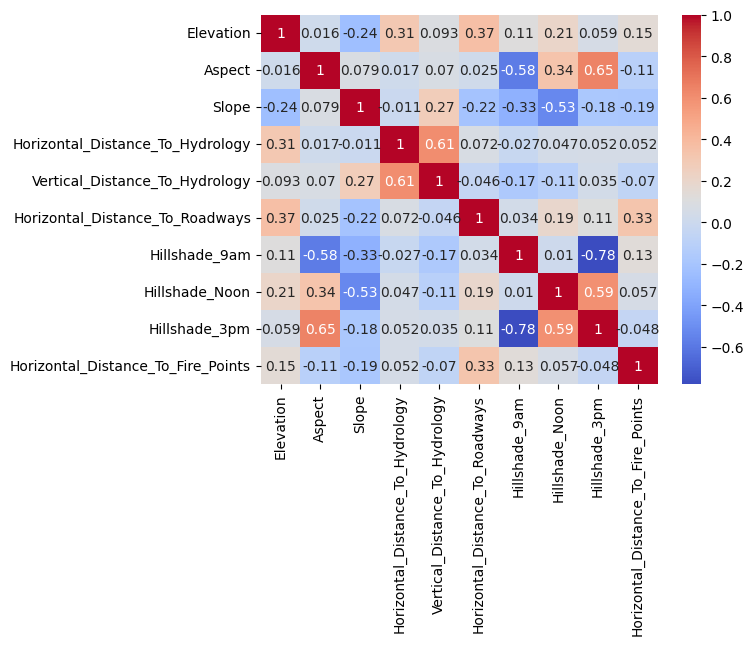

In [23]:
# 4. Correlation heatmap for continuous features
sns.heatmap(continuous_features.corr(), annot=True, cmap='coolwarm')

The most significant finding was a strong positive correlation between **Hillshade_3pm** and the other hillshade measurements (Hillshade_9am, Hillshade_Noon). Hillshade values represent the amount of illumination a surface receives at a specific time of day, and these are naturally correlated because terrain that is well-lit in the morning tends to remain relatively well-lit throughout the day.

Including highly correlated features introduces **multicollinearity**, which can make model weights unstable and adds noise without new information. `Hillshade_3pm` was therefore removed, reducing the feature set from 54 to 53.

> **Decision:** Drop `Hillshade_3pm` from all model pipelines.

---

### EDA Summary

| Finding | Impact on Modelling |
|---------|---------------------|
| Severe class imbalance | Use macro F1 as primary metric; apply class weights |
| Continuous features differ in scale | Apply StandardScaler to continuous features only |
| Hillshade_3pm correlated with other hillshade features | Remove before modelling |
| Binary features already encoded | Pass through unscaled via ColumnTransformer |

# DATA PREPROCESSING

#### Data Splitting Strategy

The data is divided into three non-overlapping sets using stratified splits at every stage. Stratification ensures that the class proportions in each split mirror those in the full dataset — without it, rare classes like Cottonwood/Willow could be severely underrepresented or entirely absent in a given split.

| Split | Proportion | Size (approx.) | Purpose |
|-------|-----------|----------------|---------|
| Training | ~64% | ~372,000 | Model weight optimisation |
| Validation | ~16% | ~93,000 | Ensemble weight optimisation, early stopping |
| Test | 20% | ~116,000 | Final evaluation only — never seen during training |

> **Important:** The test set is held out entirely until final evaluation. 
> It is never used for any tuning decision, including ensemble weight 
> optimisation. Using the test set for any tuning would constitute **data 
> leakage** and would produce overly optimistic reported results that would 
> not generalise to unseen data.

---

#### Feature Scaling

A `ColumnTransformer` is used to apply different transformations to different feature groups in a single, leak-proof step:

- **Continuous features (9):** Standardised using `StandardScaler` — each feature is shifted to zero mean and scaled to unit variance
- **Binary features (44):** Passed through unchanged with `remainder='passthrough'`

The scaler is **fitted on the training set only** and then applied to the validation and test sets. Fitting on the full dataset before splitting is a common but incorrect practice — it allows information about the test set's distribution to influence preprocessing, which inflates performance estimates.

---

#### Class Weight Computation

To counteract the class imbalance during training, class weights are computed using scikit-learn's `compute_class_weight('balanced')`. This method sets each class weight inversely proportional to its frequency in the training set — rarer classes receive higher weights, increasing the penalty for misclassifying them during training.

| Class | Frequency | Weight |
|-------|-----------|--------|
| Spruce/Fir | High | 0.39 |
| Lodgepole Pine | Highest | 0.29 |
| Ponderosa Pine | Medium | 2.32 |
| Cottonwood/Willow | Lowest | 30.20 |
| Aspen | Very low | 8.74 |
| Douglas-fir | Low | 4.78 |
| Krummholz | Low | 4.05 |

The Cottonwood/Willow weight of **30.20** reflects how rare this class is — the model is penalised 30 times more heavily for missing a Cottonwood/Willow sample than a Spruce/Fir sample. As will be seen in the results, this aggressive weighting consistently produces high recall but low precision for minority classes. The model learns to predict them often to avoid missing them, at the cost of generating false positives.

# BASELINE MODEL

#### Design Philosophy

The baseline is intentionally simple. Its purpose is not to maximise performance but to establish a reliable lower bound — a performance floor that any more complex approach must meaningfully beat to justify its additional complexity. A shallow architecture was chosen to keep the number of trainable parameters low, providing a clear contrast with the improved model.

---

#### Architecture

| Layer | Units | Activation | Parameters |
|-------|-------|------------|------------|
| Input | 53 | — | — |
| Dense | 64 | ReLU | 3,456 |
| Dense | 32 | ReLU | 2,080 |
| Output | 7 | Softmax | 231 |
| **Total** | | | **5,767** |

The output layer uses **softmax** activation, producing a probability distribution across all seven classes. The predicted class is the one with the highest probability. **Sparse categorical crossentropy** is used as the loss function, which is appropriate for integer-encoded class labels.

**Training configuration:**
- Optimiser: Adam (default learning rate 0.001)
- Batch size: 32
- Max epochs: 150
- Early stopping: patience of 10 on validation loss, restoring best weights
- Validation: explicit stratified split (20% of training data)

---

### Training Curves

<img src="../output/baseline_model_confusion_matrix.png" width="600"/>

The classification report reveals a consistent pattern across minority classes: **high recall, low precision**. The model successfully finds most instances of rare classes but casts too wide a net, pulling in many misclassified samples alongside the correct ones. This is the expected consequence of aggressive class weighting.

The most significant source of error in the confusion matrix is the bidirectional confusion between **Spruce/Fir and Lodgepole Pine** — 6,804 Spruce/Fir samples were predicted as Lodgepole Pine and 8,164 Lodgepole Pine samples were predicted as Spruce/Fir. These two species dominate the dataset and occupy overlapping cartographic profiles, making them the hardest pair to separate.

**Aspen precision of 0.35** is the weakest result — 2,834 Lodgepole Pine samples were classified as Aspen, making the false positive rate for this class particularly high. This is directly attributable to the Aspen class weight of 8.74 and will persist as a challenge throughout the project.

# IMPROVED MODEL

#### Design Philosophy

Having established a baseline, the improved model targets three specific weaknesses:

1. **Insufficient capacity** — 5,767 parameters is very limited for a 53-feature, 7-class problem with 370K+ training samples. A deeper, wider network should better capture the non-linear relationships between terrain features and cover types.

2. **No regularisation** — the baseline has no mechanism to prevent overfitting. Dropout layers are introduced to randomly deactivate neurons during training, forcing the network to learn redundant representations and reducing its dependence on any single pathway.

3. **Learning rate too coarse** — the default Adam learning rate of 0.001 takes large steps that may skip over better minima. A lower rate of 0.0005 combined with `ReduceLROnPlateau` allows finer convergence as training progresses.

---

#### Architecture

| Layer | Units | Activation | Dropout | Parameters |
|-------|-------|------------|---------|------------|
| Input | 53 | — | — | — |
| Dense | 256 | ReLU | 0.2 | 13,824 |
| Dense | 128 | ReLU | 0.2 | 32,896 |
| Dense | 64 | ReLU | 0.1 | 8,256 |
| Output | 7 | Softmax | — | 455 |
| **Total** | | | | **~55,000** |

The dropout rates are intentionally conservative — aggressive dropout on an already imbalanced dataset risks underfitting the minority classes. The rates decrease from 0.2 to 0.1 as the network narrows, reflecting the reduced representational capacity at each stage.

**Training configuration:**
- Optimiser: Adam (learning rate 0.0005)
- Batch size: 32
- Max epochs: 150
- Early stopping: patience of 10 on validation loss, restoring best weights
- `ReduceLROnPlateau`: halves learning rate after 4 epochs without improvement, minimum learning rate 1e-6
- Validation: same stratified split approach as baseline

> The epoch limit of 150 was chosen to ensure early stopping — not the epoch 
> cap — determines when training ends for both models, making the comparison 
> fair. At the lower learning rate, the improved model needs more epochs to 
> converge than the baseline.

---

#### Training Curves

<img src="../output/improved_model_training_curves.png" width="600"/>

Comparing the improved model's training curves to the baseline's reveals smoother convergence — a direct result of the lower learning rate and ReduceLROnPlateau callback. The validation loss descent is more gradual but more consistent, and the gap between training and validation curves remains narrow throughout, indicating the dropout layers are effectively preventing overfitting.

---

#### Training Curves Comparison
<img src="../output/baseline_model_training_curves.png" width="600"/>
<img src="../output/improved_model_training_curves.png" width="600"/>

Placing both models' training curves side by side highlights the trade-off between speed and stability. The baseline converges faster but with more noise in the validation curves. The improved model converges more slowly but more smoothly, ultimately reaching a better final validation loss — 0.3651 compared to 0.4632 for the baseline, a 21% reduction.

---

### Results

**Overall performance: 85.1% accuracy, macro F1 0.80**

The improved model delivers meaningful gains across six of seven classes. The most notable improvement is **Douglas-fir (+0.10 F1)**, where the deeper network learned to better separate it from Ponderosa Pine — the confusion matrix shows a clear reduction in cross-predictions between these two classes. The dominant class confusion (Spruce/Fir vs Lodgepole Pine) also improved significantly with misclassifications reducing on both sides.

The one regression is **Krummholz (-0.04 F1)** — recall increased to 0.99 but precision dropped to 0.74. The more powerful model is over-predicting Krummholz even more than the baseline did, generating additional false positives from Spruce/Fir samples. This is the same class weight overcorrection pattern seen with Aspen.

# Model Comparison & Per-Class Performance Breakdown

#### Overall Comparison

<img src="../output/ensemble_model_comparison.png" width="600"/>

| Model | Accuracy | Loss | Macro F1 | Weighted F1 |
|-------|----------|------|----------|-------------|
| Baseline | 0.81 | 0.4632 | 0.76 | 0.82 |
| Improved | **0.85** | **0.3651** | **0.80** | **0.86** |
| Ensemble Average | 0.84 | — | 0.79 | 0.85 |
| Ensemble Weighted | 0.84 | — | 0.79 | 0.85 |

The improved model is the best performer on every overall metric. The 4% accuracy gain and 21% reduction in loss are both meaningful improvements, not marginal ones. The ensemble, despite combining both models, scores below the improved model — discussed in detail in Section 8.

---

#### Per-Class Performance Breakdown

| Class | Baseline F1 | Improved F1 | Change | Notes |
|-------|------------|-------------|--------|-------|
| Spruce/Fir | 0.82 | 0.86 | +0.04 ↑ | Consistent improvement |
| Lodgepole Pine | 0.82 | 0.86 | +0.04 ↑ | Consistent improvement |
| Ponderosa Pine | 0.84 | 0.88 | +0.04 ↑ | Consistent improvement |
| Cottonwood/Willow | 0.76 | 0.79 | +0.03 ↑ | High recall maintained |
| Aspen | 0.51 | 0.58 | +0.07 ↑ | Best relative gain, precision still low |
| Douglas-fir | 0.70 | 0.80 | +0.10 ↑ | Largest absolute gain |
| Krummholz | 0.88 | 0.84 | -0.04 ↓ | Only regression — precision dropped |

**Classes that improved most:**

- **Douglas-fir** saw the largest gain because the deeper architecture learned to leverage elevation and slope features that distinguish it from the ecologically similar Ponderosa Pine. The baseline lacked the capacity to represent this boundary cleanly.

- **Aspen** showed the best relative improvement (+0.07) but remains the weakest class. Precision increased from 0.35 to 0.41 — still low, but the improved model is making fewer false positive predictions.

**Classes that regressed:**

- **Krummholz** is the only class that got worse. With a class weight of 4.05 and a more powerful model, the network over-corrects for this class even more aggressively than the baseline, trading precision for near-perfect recall. This is a diminishing-returns effect of class weighting in higher-capacity networks.

---

#### The Persistent Precision Problem

Across every model evaluated, the same pattern appears for minority classes: recall is high (often above 0.90) but precision is low (often below 0.65). This is not a failure of the model architecture — it is an inherent consequence of class weighting.

When a class weight of 8.74 (Aspen) tells the model "missing an Aspen sample costs 8.74 times more than missing a Spruce/Fir sample," the model learns a rational response: predict Aspen whenever there is any doubt. This maximises recall at the expense of precision. No amount of architectural improvement will fully resolve this without adjusting the weights themselves.

The right remedy is **manual class weight tuning** — reducing minority class weights slightly to find the precision-recall balance that best fits the intended use case. Whether recall or precision matters more depends entirely on what this classifier would be used for in practice.

# ENSEMBLE

#### Motivation

Ensemble methods combine the predictions of multiple models with the goal of producing a result better than any single model can achieve alone. They are most effective when the constituent models make **different types of errors** — one model's mistakes are corrected by the other's correct predictions.

Two ensemble strategies were evaluated:

| Strategy | Description |
|----------|-------------|
| **Average** | Each model contributes equally (0.5/0.5) to the final probability |
| **Weighted** | Weights optimised on the validation set to maximise macro F1 |

---

#### Weight Optimisation

Optimal ensemble weights were found using **scipy's L-BFGS-B optimiser** — a bounded gradient-based method that constrains weights to the range [0, 1]. This is preferred over the unconstrained Nelder-Mead method, which can produce negative weights that have no meaningful interpretation in a probability averaging context.

The objective function being minimised is the **negative macro F1 score** on the validation set predictions. The optimisation was performed exclusively on the validation set — using the test set for this purpose would allow the ensemble weights to be tuned to the specific test samples, inflating reported performance and undermining the integrity of the final evaluation.

**Optimal weights found: Model 1 (Baseline) = 0.500, Model 2 (Improved) = 0.500**

The optimiser converging to exactly 0.5/0.5 is itself an informative result — it means no asymmetric weighting produced a better macro F1 on the validation set than simple averaging. This is an early indicator that the ensemble may not outperform the improved model alone.

---

#### Results

| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| Baseline | 0.81 | 0.76 | 0.82 |
| **Improved** | **0.85** | **0.80** | **0.86** |
| Ensemble Average | 0.84 | 0.79 | 0.85 |
| Ensemble Weighted | 0.84 | 0.79 | 0.85 |

Both ensemble methods score **0.84 accuracy and 0.79 macro F1** — below the improved model's 0.85 and 0.80 respectively. Since the optimal weights were 0.5/0.5, the average and weighted ensembles produce identical results.

---

#### Why the Ensemble Did Not Help

This is a textbook outcome for ensembling two models of unequal quality. The baseline, scoring 0.81 accuracy, introduces errors that the improved model does not make. Averaging in those incorrect predictions dilutes the improved model's better decisions rather than correcting them.

Ensembling is most valuable when:
1. Both models perform similarly overall
2. Their errors occur on different samples
3. Each model has a distinct architectural or data perspective

None of these conditions are strongly met here. The improved model is consistently better across almost every class, so averaging it with a weaker model can only move results toward the weaker model's territory.

**One exception — Krummholz:**

The baseline outperformed the improved model on Krummholz (F1 0.88 vs 0.84). Averaging the two predictions brings the ensemble Krummholz F1 to 0.87 — recovering most of the regression. This demonstrates that even when a global ensemble is not beneficial, there can be value in **per-class ensemble strategies** that selectively use each model's strengths.

**Conclusion: The Improved Model is selected as the final model.**

# KEY INSIGHTS & OBSERVATIONS

This section consolidates the most important findings from the full pipeline into a concise reference.

---

#### Architecture Depth Matters More Than Width Alone
Increasing capacity from 5,767 to ~55,000 parameters produced consistent gains across six of seven classes. The deeper architecture learned more nuanced decision boundaries — particularly evident in the Douglas-fir/Ponderosa Pine separation, which requires combining multiple terrain signals that a two-layer network cannot represent sufficiently.

#### Class Weighting Is a Double-Edged Sword
Class weights successfully prevented the model from ignoring rare species — every class achieved recall above 0.83 in the improved model. However, the same mechanism consistently produces low precision for minority classes. The relationship is direct: the higher the class weight, the higher the recall and the lower the precision. Aspen (weight 8.74, precision 0.41) and Cottonwood/Willow (weight 30.20, precision 0.67) illustrate this most clearly.

#### A Fair Comparison Requires a Fair Epoch Budget
When both models were initially run at 50 epochs, the improved model appeared worse than the baseline. This was because the lower learning rate (0.0005) meant the improved model had not converged by epoch 50 — the baseline, using the default rate of 0.001, converged faster. Running both models with a ceiling of 150 epochs and letting early stopping determine convergence produced a fair and meaningful comparison.

#### Ensembling Does Not Always Improve Results
A common misconception is that combining models always improves performance. This project demonstrates clearly that ensembling a strong model with a noticeably weaker one degrades overall performance. The performance gap between models must be small and their errors complementary for ensembling to be worthwhile.

#### Dominant Class Confusion Is the Largest Source of Error
Across all models, the single biggest source of misclassification is the bidirectional confusion between Spruce/Fir and Lodgepole Pine. These two classes account for over 85% of the dataset and occupy overlapping elevation and terrain ranges. Even the best model (improved) misclassifies 4,801 Spruce/Fir samples as Lodgepole Pine and 5,637 Lodgepole Pine samples as 
Spruce/Fir. Reducing this confusion would have the largest single impact on overall accuracy.

#### Validation Strategy Affects Results More Than Expected
Replacing Keras's built-in `validation_split=0.2` with an explicit stratified split had a measurable impact. Keras's `validation_split` takes the last 20% of training data sequentially without shuffling or stratifying — on a dataset with any natural ordering, this produces a biased validation set. The explicit stratified split ensures the validation set faithfully represents the true class distribution, producing more reliable early stopping decisions.

# NEXT STEPS & IMPROVEMENTS

The following improvements are ranked by expected impact and implementation effort.

---

#### Tune Class Weights Manually *(High Impact, Low Effort)*
The persistent low precision on Aspen, Cottonwood/Willow and Krummholz is a class weighting problem, not an architectural one. Reducing the Aspen weight from 8.74 toward 5–6 and the Cottonwood/Willow weight from 30.20 toward 15–20 would trade some recall for meaningful precision gains. Whether this trade-off is acceptable depends on the deployment context — in a conservation application, missing a rare species may be more costly than a false positive; in a land management system, false positives may cause operational problems. Either way, the current weights were computed automatically and may not reflect the true cost structure of the problem.

#### Enable GPU Training via WSL2 + CUDA *(High Impact, Medium Effort)*
All training in this project was performed on CPU. The test machine has an NVIDIA GeForce RTX 3050 Ti (4GB VRAM) which is more than capable of accelerating this workload, but TensorFlow 2.11+ dropped native Windows GPU support. Setting up WSL2 with CUDA would deliver an estimated 5–10× speedup, enabling faster iteration on architecture experiments and larger batch sizes. This is a one-time setup that benefits all future deep learning projects.

#### Add Batch Normalisation *(Medium Impact, Low Effort)*
Inserting a `BatchNormalization` layer after each Dense layer normalises activations at each step of training, which typically accelerates convergence, reduces sensitivity to the learning rate and can improve final performance. It is a low-risk addition — if it does not help it can simply be removed.

```python
# Example addition to improved model architecture
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
```
#### Benchmark Against Tree-Based Methods (High Impact, Medium Effort)
Neural networks are not always the best tool for tabular classification problems. Random Forest and XGBoost are known to perform exceptionally well on the Covertype dataset — published benchmarks report accuracies above 95% with well-tuned gradient boosting. Running these as comparison baselines would contextualise the neural network results and determine whether the additional complexity of a deep learning approach is actually justified for this problem.

#### Per-Class Ensemble Weighting (Medium Impact, High Effort)
The current ensemble uses a single global weight pair applied uniformly across all classes. A more sophisticated approach would optimise separate weights for each class — using the baseline's stronger Krummholz predictions selectively while deferring to the improved model for all other classes. This would require a post-processing step that selects predictions class-by-class rather than averaging raw probability vectors.

#### Hyperparameter Search (Medium Impact, High Effort)
The current architecture and training configuration were chosen through informed manual iteration. A systematic hyperparameter search usingkeras-tuner or optuna over learning rate, layer sizes, dropout rates and batch size could identify configurations that outperform the current improved model. With GPU acceleration (see 10.2) this becomes computationally feasible.
